In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [15]:
x = np.linspace(-6 , 6 ,100)
y = np.sqrt(10**2 - x**2)
y = np.hstack((y, -y))
x = np.hstack((x , -x))

In [18]:
x1 = np.linspace(-6 , 6 ,100)
y1 = np.sqrt(4**2 - x1**2)
y1 = np.hstack((y1 , -y1))
x1 = np.hstack((x1 , x1))

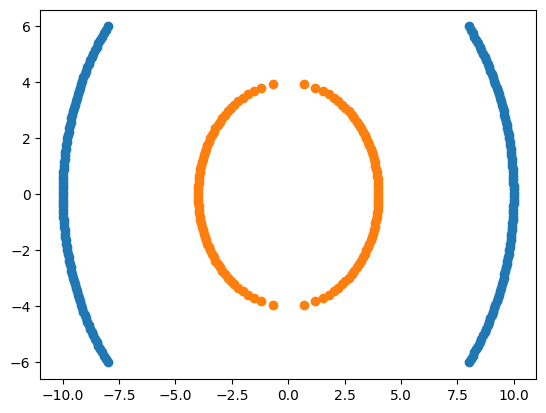

In [19]:
plt.scatter(y,x)
plt.scatter(y1,x1)


In [20]:
df1 = pd.DataFrame(np.vstack((y,x)).T , columns = ["x1","x2"])
df1["y"]= 0
df1

,x1,x2,y
0,8.000000,-6.000000,0
1,8.089490,-5.878788,0
2,8.176205,-5.757576,0
3,8.260230,-5.636364,0
4,8.341649,-5.515152,0
...,...,...,...
195,-8.341649,-5.515152,0
196,-8.260230,-5.636364,0
197,-8.176205,-5.757576,0
198,-8.089490,-5.878788,0


In [21]:
df2 = pd.DataFrame(np.vstack((y1,x1)).T , columns = ["x1","x2"])
df2["y"] = 1
df2

,x1,x2,y
0,NaN,-6.000000,1
1,NaN,-5.878788,1
2,NaN,-5.757576,1
3,NaN,-5.636364,1
4,NaN,-5.515152,1
...,...,...,...
195,NaN,5.515152,1
196,NaN,5.636364,1
197,NaN,5.757576,1
198,NaN,5.878788,1


In [22]:
df = pd.concat((df1,df2) , ignore_index = True)
df.head()

,x1,x2,y
0,8.000000,-6.000000,0
1,8.089490,-5.878788,0
2,8.176205,-5.757576,0
3,8.260230,-5.636364,0
4,8.341649,-5.515152,0


In [23]:
df1= df.copy()

In [25]:
df1["x1square"] = df1["x1"]**2
df1["x2square"] = df1["x2"]**2
df1["x1x2"] = df1["x1"]*df1["x2"]
df1.head()

,x1,x2,y,x1square,x2square,x1x2
0,8.000000,-6.000000,0,64.000000,36.000000,-48.000000
1,8.089490,-5.878788,0,65.439853,34.560147,-47.556397
2,8.176205,-5.757576,0,66.850321,33.149679,-47.075117
3,8.260230,-5.636364,0,68.231405,31.768595,-46.557662
4,8.341649,-5.515152,0,69.583104,30.416896,-46.005457


In [36]:
df1 =df1.dropna()

In [37]:
X = df1[["x1square", "x2square", "x1x2"]]
y = df1["y"]

In [38]:
y.value_counts()

y
0    200
1    132
Name: count, dtype: int64

In [39]:
from sklearn.model_selection import train_test_split
X_train , X_test , y_train , y_test = train_test_split(X,y , test_size = 0.2 , random_state = 42)

In [40]:
X_train.shape , X_test.shape

((265, 3), (67, 3))

In [35]:
import plotly.express as px
fig = px.scatter_3d(df1 , x = "x1square" , y = "x2square" , z = "x1x2" , color = "y")
fig.show()

In [41]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

cls = SVC(kernel = "linear")
cls.fit(X_train , y_train)
y_pred = cls.predict(X_test)
accuracy_score(y_test , y_pred)

1.0

In [42]:
#till now we have done manually
#we will use svc kernel's

In [43]:
df = df.dropna()

In [44]:
df.head()

,x1,x2,y
0,8.000000,-6.000000,0
1,8.089490,-5.878788,0
2,8.176205,-5.757576,0
3,8.260230,-5.636364,0
4,8.341649,-5.515152,0


In [47]:
X = df[["x1", "x2"]]
y = df["y"]

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=1)

In [48]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

model = SVC(kernel = "rbf") #radial basis function
model.fit(X_train , y_train)
y_pred = model.predict(X_test)  
accuracy_score(y_test , y_pred)

1.0

In [ ]:
#internal homework>> try to do kernel hyperparameter tuning using grid search cv

from sklearn.model_selection import GridSearchCV

param_grid = {'C': [0.1, 1, 10], 'gamma': [0.1, 1, 10]}
model = SVC(kernel='rbf')
grid_search = GridSearchCV(model, param_grid, cv=5)
grid_search.fit(X_train, y_train)
print(grid_search.best_params_)



{'C': 0.1, 'gamma': 0.1}


In [52]:
from sklearn.metrics import accuracy_score
best_model = grid_search.best_estimator_
best_model.fit(X_train , y_train)
y_pred = best_model.predict(X_test)
accuracy_score(y_test , y_pred)

1.0